In [1]:
import matplotlib.pyplot as plt
%matplotlib ipympl

# How to use

## Installation

Install using `pip`

```
pip install gitblabla
```

## Calculate CPSDs and statistics

Generally, calculate the CPSD matrix of a few time series (synchronously sampled) with the class :class:`noisefinder.CPSDstats`.\
Note that :class:`noisefinder.CPSDstats` does not include a *frequency scheme*, i.e., a set of frequencies, stretch length, and Fourier index at which to calculate the CPSDs.\
The experienced user can create their own classes, which inherit from :class:`noisefinder.CPSDstats` and use it for CPSD evaluation and statistics.\
In `noisefinder`, we provide useful frequency schemes:
- The *LPF frequency scheme*, :class:`noisefinder.CPSD_LPFmethod`, with logarithmic-spaced frequencies and stretch lengths, and constant Fourier index (see :class:`noisefinder.CPSD_LPFmethod` for details).
- The *WOSA (Welch) frequency scheme*, :class:`noisefinder.CPSD_WOSAmethod`, with linearly-spaced frequencies, and a single stretch length.
  
For this example, we implement the LPF method, and a give an introductory example.

In [2]:
import noisefinder
import numpy as np
import scipy.stats as st
import scipy.signal as sig

Just generate two time series with white and `1/f^2` ASD noise spectrum, for this example.\
Calculate the Welch PSD for comparison.

In [3]:
datA = np.cumsum(st.norm.rvs(size=100000))
datB = 1000*st.norm.rvs(size=100000)
fs = 10 #sampling frequency

#calculate welch for comparison
PSDfA,PSDvA = sig.welch(datA,fs=10,window='blackmanharris',nperseg=20000)
PSDfB,PSDvB = sig.welch(datB,fs=10,window='blackmanharris',nperseg=20000)

Now create a :class:`noisefinder.CPSD_LPFmethod` instance. It already implements the LPF frequency scheme and calculates the CPSD matrices at those frequencies.

In [4]:
meas_LPFmethod = noisefinder.CPSD_LPFmethod(ts=[datA,datB],fs=fs,Tmax=2000,fmax=1)

It saves useful parameters as class attributes (see full list at :class:`noisefinder.CPSDstats`):

In [5]:
meas_LPFmethod.CPSD  # The CPSD matrix, at the Fourier frequencies
meas_LPFmethod.PSD   # The PSDs of the input time series, at the Fourier frequencies
meas_LPFmethod.freqs # The Fourier frequencies
meas_LPFmethod.navs  # The number of averaged periodograms, useful for confidence interval evaluation
meas_LPFmethod.cohere # Coherencies
meas_LPFmethod.Ls # The stretch length (number of samples) for CPSD evaluation at each frequency.

array([20000, 20000, 12000,  7200,  4319,  2592,  1555,   933,   559,
         335,   201,   120])

Calculate the PSD posterior confidence interval (for instance, at 0.68 - 1 sigma confidence level).

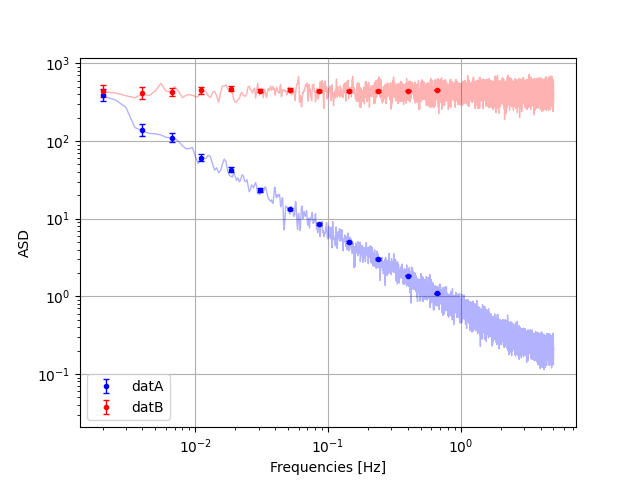

In [6]:
#extract quantiles
meas_LPFmethod_PSDq = meas_LPFmethod.PSDquantiles_eval(cval=0.68)
meas_LPFmethod_PSDq_datA = meas_LPFmethod_PSDq[0,:,:]
meas_LPFmethod_PSDq_datB = meas_LPFmethod_PSDq[1,:,:]

fig,ax=plt.subplots()
ax.loglog(PSDfA[4:],np.sqrt(PSDvA[4:]),lw=1, c='b', alpha=0.3)
ax.loglog(PSDfB[4:],np.sqrt(PSDvB[4:]),lw=1, c='r', alpha=0.3)

ax.errorbar(meas_LPFmethod.freqs,
            np.sqrt(meas_LPFmethod_PSDq_datA[1,:]),
            yerr = [np.sqrt(meas_LPFmethod_PSDq_datA[1,:])-np.sqrt(meas_LPFmethod_PSDq_datA[0,:]),
                    np.sqrt(meas_LPFmethod_PSDq_datA[2,:])-np.sqrt(meas_LPFmethod_PSDq_datA[1,:])],
            linestyle='',capsize=2.5,lw=1,c='b',fmt='.',label='datA')
ax.errorbar(meas_LPFmethod.freqs,
            np.sqrt(meas_LPFmethod_PSDq_datB[1,:]),
            yerr = [np.sqrt(meas_LPFmethod_PSDq_datB[1,:])-np.sqrt(meas_LPFmethod_PSDq_datB[0,:]),
                    np.sqrt(meas_LPFmethod_PSDq_datB[2,:])-np.sqrt(meas_LPFmethod_PSDq_datB[1,:])],
            linestyle='',capsize=2.5,lw=1,c='r',fmt='.',label='datB')
ax.grid(); ax.set_xlabel('Frequencies [Hz]'); ax.set_ylabel('ASD'); ax.legend()
plt.show()

We can also calculate the MSC between the two series, whose true values in our example is zero.

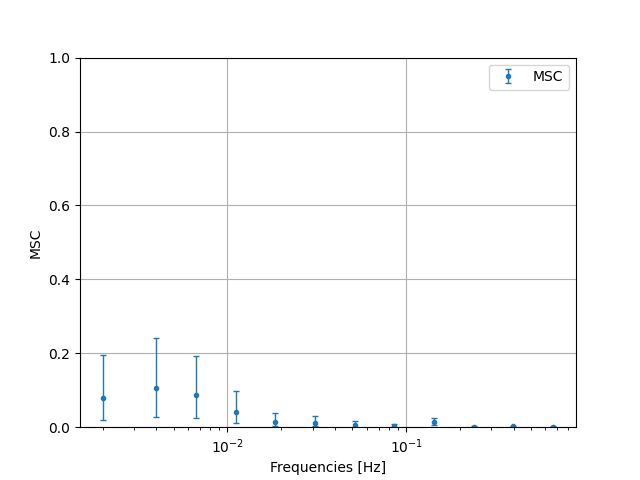

In [7]:
#same goes for MSC between two ts and R2

meas_LPFmethod_MSCq_AB = meas_LPFmethod.MSCquantiles_eval(idx1=0,idx2=1,cval=0.68)

fig,ax=plt.subplots()
ax.errorbar(x=meas_LPFmethod.freqs,
            y=meas_LPFmethod_MSCq_AB[:,1],
            yerr = [meas_LPFmethod_MSCq_AB[:,1]-meas_LPFmethod_MSCq_AB[:,0],meas_LPFmethod_MSCq_AB[:,2]-meas_LPFmethod_MSCq_AB[:,1]],
            linestyle='',capsize=2.5,lw=1,c='C0',fmt='.',label='MSC')
ax.grid(); ax.set_ylim([0,1]); ax.set_xscale('log'); ax.legend()
ax.set_xlabel('Frequencies [Hz]'); ax.set_ylabel('MSC');
plt.show()

## Only calculate CPSD statistics

The user could also be interested in calculating PSD statistics (or MSC) of a single measured PSD sample, without using the functionalities of :class:`noisefinder.CPSD_LPFmethod`.\
This can be done:

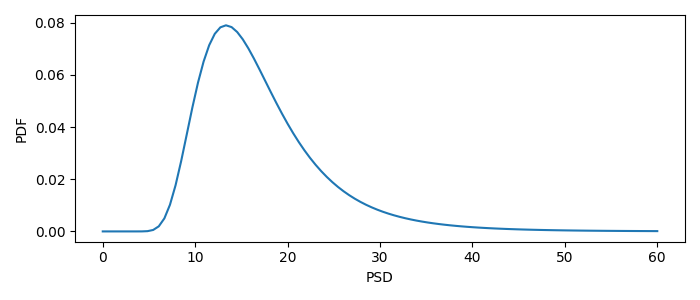

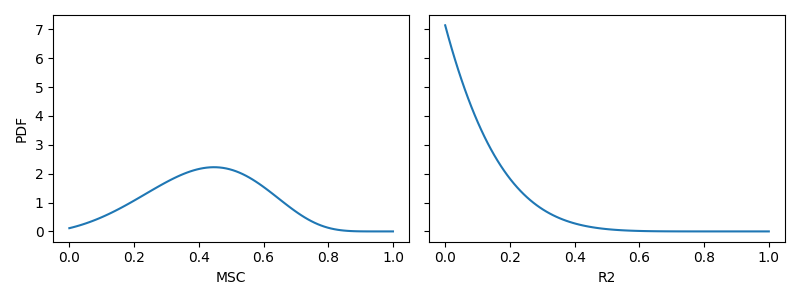

In [13]:
from noisefinder.CPSDstats import CPSDstats_methods as cpm

PSDpp = cpm.PSDposterior(expPSD=15.0,navs=8)     # PSD posterior, as frozen scipy.stats, of the PSD posterior 
PSDCI = cpm.PSDpostCI(expPSD=15.0,navs=8,c=0.68) # PSD posterior confidence interval at given confidence level

rho2th=np.linspace(0,1,100)
rho2pp = cpm.rho2posterior(rho2th=rho2th,rho2exp=0.5,navs=8) # MSC posterior evaluated on the rho2th axis 
rho2CI = cpm.rho2postCI(r2e=0.5,navs=8,c=0.68) # MSC posterior confidence interval at given confidence level

R2th=np.linspace(0,1,100)
R2pp = cpm.R2posterior(R2th=R2th,R2exp=0.1,navs=8,p=4) # R2 posterior, evaluated on the R2th axis. p is the number of timeseries
R2CI = cpm.R2postCI(R2e=0.1,navs=8,p=4,c=0.68) # R2 posterior confidence interval at given confidence level

PSDaxis = np.linspace(0,60,100)
fig,ax=plt.subplots(figsize=(7,3))
ax.plot(PSDaxis,PSDpp.pdf(PSDaxis))
ax.set_xlabel('PSD'); ax.set_ylabel('PDF')
fig.tight_layout()

fig,ax=plt.subplots(1,2,figsize=(8,3),sharey=True,sharex=True)
ax[0].plot(rho2th,rho2pp)
ax[0].set_xlabel('MSC'); ax[0].set_ylabel('PDF')

ax[1].plot(R2th,R2pp)
ax[1].set_xlabel('R2'); #ax[1].set_ylabel('PDF')
fig.tight_layout()

In [9]:
class CPSD_custom(noisefinder.CPSDstats):
    def __init__(self,ts,fs,detrend_c=False,verbose=False): # more user-defined params
        win = noisefinder.specwindows.BH92 #user-defined
        olap = 50 #user-defined 
        super().__init__(ts=ts,fs=fs,win=win,olap=50,detrend_c=detrend_c)
        freqs = np.array([0.004, 0.0066667, 0.0111111]) #user-defined, with external method
        Ls = np.array([20000, 12000, 7200]) #user-defined, with external method
        kcoeffs = np.array([8,8,8]) #user-defined, with external method
        self.CPSD_eval(freqs,Ls,kcoeffs) #explicitly evaluate CPSD matrices

meas_custom = CPSD_custom(ts=[datA,datB],fs=fs)